In [3]:

import pandas as pd
import matplotlib.pyplot as plt
from google_ngram_downloader import GoogleNgramDownloader

# First install the package if you haven't already
# !pip install google-ngram-downloader

# Initialize the downloader
downloader = GoogleNgramDownloader()

# Create empty dictionaries to store the data
democracy_data = {'year': [], 'frequency': []}
liberty_data = {'year': [], 'frequency': []}

# Download and process the data
for fname, url, records in downloader.get_ngram_data(ngram_len=1, indices=['democracy', 'liberty']):
    for record in records:
        if record.ngram == 'democracy':
            democracy_data['year'].append(record.year)
            democracy_data['frequency'].append(record.match_count / record.volume_count)
        elif record.ngram == 'liberty':
            liberty_data['year'].append(record.year)
            liberty_data['frequency'].append(record.match_count / record.volume_count)

# Create DataFrames
democracy_df = pd.DataFrame(democracy_data)
liberty_df = pd.DataFrame(liberty_data)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(democracy_df['year'], democracy_df['frequency'], label='democracy')
plt.plot(liberty_df['year'], liberty_df['frequency'], label='liberty')
plt.xlabel("Year")
plt.ylabel("Relative Frequency")
plt.title("Frequency of 'Democracy' and 'Liberty' in Google Books (1800-2019)")
plt.legend()
plt.savefig("ngram_democracy_liberty.png")
plt.show()

"""---

5.3 Understanding Semantic Drift with Time-Aware Word Embeddings
What is Semantic Drift?
Semantic drift refers to how the meaning of words changes over time. For example, liberty in the 18th century may have been associated with republicanism and constitutionalism, whereas in the 21st century, it may relate more to civil liberties and human rights.
Using Word Embeddings to Track Meaning Over Time
A word embedding is a mathematical representation of a word based on its context. By training embeddings on historical texts from different time periods, we can see how a word's meaning has changed.
To analyze democracy and liberty, we will:
Use historical corpora (e.g., COHA, Google Books) to train time-aware embeddings.
Measure the semantic similarity of these words across decades.
Visualize how their meanings have shifted.

---"""
"""
5.4 Training Time-Aware Word Embeddings
We train separate word embeddings for different time periods using Word2Vec on Google Books data."""
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
# Load historical text datasets (pre-cleaned)
text_1800s = open("books_1800s.txt").read().lower()
text_1900s = open("books_1900s.txt").read().lower()
text_2000s = open("books_2000s.txt").read().lower()
# Tokenize
tokens_1800s = [word_tokenize(text_1800s)]
tokens_1900s = [word_tokenize(text_1900s)]
tokens_2000s = [word_tokenize(text_2000s)]
# Train Word2Vec models for different eras
model_1800s = Word2Vec(tokens_1800s, vector_size=100, window=5, min_count=5, sg=0)
model_1900s = Word2Vec(tokens_1900s, vector_size=100, window=5, min_count=5, sg=0)
model_2000s = Word2Vec(tokens_2000s, vector_size=100, window=5, min_count=5, sg=0)

"""---

5.5 Measuring Semantic Change Over Time
To track semantic drift, we measure how the nearest words to democracy and liberty change over time."""
# Get top similar words for democracy
print("1800s:", model_1800s.wv.most_similar("democracy", topn=5))
print("1900s:", model_1900s.wv.most_similar("democracy", topn=5))
print("2000s:", model_2000s.wv.most_similar("democracy", topn=5))


ImportError: cannot import name 'GoogleNgramDownloader' from 'google_ngram_downloader' (/usr/local/lib/python3.11/dist-packages/google_ngram_downloader/__init__.py)

In [4]:
import requests
import pandas as pd
import plotly.express as px

# First install plotly if you haven't
# !pip install plotly

def get_ngram_data(words, start_year=1800, end_year=2019):
    # Create the Google Ngram API URL
    base_url = "https://books.google.com/ngrams/json"
    content = f"{','.join(words)}"
    url = f"{base_url}?content={content}&year_start={start_year}&year_end={end_year}&corpus=26&smoothing=3"

    # Get the data
    response = requests.get(url)
    data = response.json()

    # Process the data into a DataFrame
    df_list = []
    for series in data:
        word = series['ngram']
        years = series['timeseries']
        df = pd.DataFrame({
            'year': range(start_year, end_year + 1),
            'frequency': years,
            'word': word
        })
        df_list.append(df)

    return pd.concat(df_list)

# Get the data
df = get_ngram_data(['democracy', 'liberty'])

# Create the plot using plotly
fig = px.line(df, x='year', y='frequency', color='word',
              title='Frequency of "Democracy" and "Liberty" in Google Books (1800-2019)')
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Relative Frequency (%)",
    legend_title="Word"
)

# Show the plot
fig.show()

# Save the plot if needed
fig.write_html("ngram_plot.html")


In [5]:
import gensim
import numpy as np
from scipy.spatial.distance import cosine
import requests
import io
import zipfile

# First, let's install required packages
# !pip install gensim numpy scipy requests

def download_historical_embeddings():
    """Download pre-trained historical word embeddings"""
    url = "https://nlp.stanford.edu/projects/histwords/eng-all_sgns.zip"
    response = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(response.content))
    return z

def load_embeddings(decade):
    """Load embeddings for a specific decade"""
    filename = f"eng-{decade}.txt"
    vectors = {}
    with open(filename, 'r', encoding='utf-8') as f:
        next(f)  # Skip header
        for line in f:
            values = line.strip().split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            vectors[word] = vector
    return vectors

# Define decades we want to analyze
decades = ['1800s', '1900s', '2000s']

try:
    # Download and extract embeddings
    print("Downloading historical embeddings...")
    embeddings_zip = download_historical_embeddings()
    embeddings_zip.extractall()

    # Load embeddings for each decade
    embeddings = {decade: load_embeddings(decade) for decade in decades}

    # Function to get similar words
    def get_similar_words(word, embeddings_dict, topn=5):
        target_vector = embeddings_dict[word]
        similarities = []
        for w, vec in embeddings_dict.items():
            if w != word:
                similarity = 1 - cosine(target_vector, vec)
                similarities.append((w, similarity))
        return sorted(similarities, key=lambda x: x[1], reverse=True)[:topn]

    # Analyze semantic drift for 'democracy' and 'liberty'
    words = ['democracy', 'liberty']

    for word in words:
        print(f"\nSemantic drift analysis for '{word}':")
        for decade in decades:
            similar_words = get_similar_words(word, embeddings[decade])
            print(f"\n{decade}:")
            for similar_word, similarity in similar_words:
                print(f"  {similar_word}: {similarity:.4f}")

        # Calculate semantic change between decades
        print(f"\nSemantic change magnitude for '{word}':")
        for i in range(len(decades)-1):
            vec1 = embeddings[decades[i]][word]
            vec2 = embeddings[decades[i+1]][word]
            change = cosine(vec1, vec2)
            print(f"{decades[i]} to {decades[i+1]}: {change:.4f}")

except Exception as e:
    print(f"An error occurred: {str(e)}")
    print("\nAs an alternative, here's a simplified demonstration using mock data:")

    # Mock data for demonstration
    mock_similar_words = {
        'democracy': {
            '1800s': [('republic', 0.8), ('sovereignty', 0.75), ('constitution', 0.7)],
            '1900s': [('government', 0.85), ('freedom', 0.8), ('elections', 0.75)],
            '2000s': [('democratic', 0.9), ('governance', 0.85), ('participation', 0.8)]
        },
        'liberty': {
            '1800s': [('freedom', 0.85), ('rights', 0.8), ('independence', 0.75)],
            '1900s': [('freedom', 0.9), ('civil_rights', 0.85), ('justice', 0.8)],
            '2000s': [('freedom', 0.95), ('human_rights', 0.9), ('equality', 0.85)]
        }
    }

    # Print mock results
    for word in mock_similar_words:
        print(f"\nSemantic drift analysis for '{word}' (mock data):")
        for decade in decades:
            print(f"\n{decade}:")
            for similar_word, similarity in mock_similar_words[word][decade]:
                print(f"  {similar_word}: {similarity:.4f}")



An error occurred: File is not a zip file

As an alternative, here's a simplified demonstration using mock data:

Semantic drift analysis for 'democracy' (mock data):

1800s:
  republic: 0.8000
  sovereignty: 0.7500
  constitution: 0.7000

1900s:
  government: 0.8500
  freedom: 0.8000
  elections: 0.7500

2000s:
  democratic: 0.9000
  governance: 0.8500
  participation: 0.8000

Semantic drift analysis for 'liberty' (mock data):

1800s:
  freedom: 0.8500
  rights: 0.8000
  independence: 0.7500

1900s:
  freedom: 0.9000
  civil_rights: 0.8500
  justice: 0.8000

2000s:
  freedom: 0.9500
  human_rights: 0.9000
  equality: 0.8500


In [7]:
import numpy as np
import pandas as pd
from gensim.models import KeyedVectors
import requests
import os
import tarfile
from io import BytesIO

# Create a directory for the models
if not os.path.exists('historical_vectors'):
    os.makedirs('historical_vectors')

# Download from Stanford NLP's repository
base_url = "https://nlp.stanford.edu/data/glove.6B.zip"
decades = ['1840', '1890', '1940', '1990']

def download_and_process_vectors():
    print("Downloading word vectors...")
    response = requests.get("http://downloads.cs.stanford.edu/nlp/data/wordvecs/en.zip")

    if response.status_code == 200:
        print("Processing downloaded data...")
        with BytesIO(response.content) as bio:
            with tarfile.open(fileobj=bio, mode='r:gz') as tar:
                for decade in decades:
                    member = tar.getmember(f'en/en.{decade}.txt')
                    tar.extract(member, 'historical_vectors')
    else:
        raise Exception("Failed to download vectors")

try:
    # Try to download vectors
    download_and_process_vectors()
except Exception as e:
    print(f"Error downloading vectors: {str(e)}")
    print("Using alternative source...")

    # Alternative: Use pre-trained Word2Vec models
    from gensim.downloader import load

    print("Loading word2vec-google-news model...")
    model = load("word2vec-google-news-300")

    # Function to analyze semantic relationships
    def analyze_semantic_relationships(word, model):
        try:
            # Get similar words
            similar_words = model.most_similar(word, topn=10)
            print(f"\nSemantic analysis for '{word}':")
            for similar_word, similarity in similar_words:
                print(f"  {similar_word}: {similarity:.4f}")

            # Get specific relationships
            analogies = [
                ('democracy', 'government'),
                ('liberty', 'freedom'),
                ('democracy', 'republic'),
                ('liberty', 'rights')
            ]

            print(f"\nWord relationships:")
            for w1, w2 in analogies:
                try:
                    similarity = model.similarity(w1, w2)
                    print(f"  {w1} - {w2}: {similarity:.4f}")
                except KeyError:
                    print(f"  Cannot compute similarity for {w1} - {w2}")

        except KeyError:
            print(f"Word '{word}' not found in the vocabulary")

    # Analyze our target words
    words = ['democracy', 'liberty']
    for word in words:
        analyze_semantic_relationships(word, model)

    # Visualize semantic space
    import matplotlib.pyplot as plt
    from sklearn.manifold import TSNE

    def visualize_semantic_space(word, model, n_neighbors=10):
        try:
            # Get similar words and their vectors
            similar_words = [word] + [w for w, _ in model.most_similar(word, topn=n_neighbors)]
            vectors = [model[w] for w in similar_words]

            # Reduce dimensionality
            tsne = TSNE(n_components=2, random_state=42)
            vectors_2d = tsne.fit_transform(vectors)

            # Plot
            plt.figure(figsize=(12, 8))
            plt.scatter(vectors_2d[1:, 0], vectors_2d[1:, 1], c='blue', alpha=0.5)
            plt.scatter(vectors_2d[0, 0], vectors_2d[0, 1], c='red', s=100)

            # Add labels
            for i, word in enumerate(similar_words):
                plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

            plt.title(f"Semantic space around '{word}'")
            plt.savefig(f"semantic_space_{word}.png")
            plt.close()

        except KeyError:
            print(f"Cannot visualize semantic space for '{word}' (word not found)")

    # Create visualizations
    for word in words:
        visualize_semantic_space(word, model)

    # Additional analysis: Create word clusters
    from sklearn.cluster import KMeans

    def analyze_word_clusters(words, model, n_related=20):
        # Collect related words
        all_words = set()
        word_vectors = []
        word_labels = []

        for word in words:
            try:
                related = [w for w, _ in model.most_similar(word, topn=n_related)]
                all_words.update([word] + related)
            except KeyError:
                continue

        # Get vectors for all words
        for word in all_words:
            word_vectors.append(model[word])
            word_labels.append(word)

        # Cluster the vectors
        kmeans = KMeans(n_clusters=3, random_state=42)
        clusters = kmeans.fit_predict(word_vectors)

        # Visualize clusters
        tsne = TSNE(n_components=2, random_state=42)
        vectors_2d = tsne.fit_transform(word_vectors)

        plt.figure(figsize=(12, 8))
        scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=clusters, cmap='viridis')

        # Add labels
        for i, word in enumerate(word_labels):
            plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

        plt.title("Word Clusters")
        plt.colorbar(scatter)
        plt.savefig("word_clusters.png")
        plt.close()

    # Create word clusters
    analyze_word_clusters(words, model)



Error downloading vectors: Failed to download vectors
Using alternative source...
Loading word2vec-google-news model...
[==================================================] 100.0% 1662.8/1662.8MB downloaded

Semantic analysis for 'democracy':
  democratic: 0.8644
  participatory_democracy: 0.7171
  democracies: 0.7103
  democratization: 0.7039
  pluralism: 0.6955
  multiparty_democracy: 0.6910
  democractic: 0.6702
  democratic_ideals: 0.6659
  pluralist_democracy: 0.6641
  constitutionalism: 0.6593

Word relationships:
  democracy - government: 0.4179
  liberty - freedom: 0.7535
  democracy - republic: 0.5931
  liberty - rights: 0.4199

Semantic analysis for 'liberty':
  freedom: 0.7535
  freedoms: 0.7339
  liberties: 0.7176
  democracy: 0.5967
  unalienable_rights: 0.5878
  civil_liberties: 0.5847
  unalienable: 0.5811
  First_Amendment_freedoms: 0.5740
  Constitutionally_guaranteed: 0.5636
  fundamental_freedoms: 0.5569

Word relationships:
  democracy - government: 0.4179
  liberty

AttributeError: 'list' object has no attribute 'shape'

Loading word2vec-google-news model...

Semantic analysis for 'democracy':
  democratic: 0.8644
  participatory_democracy: 0.7171
  democracies: 0.7103
  democratization: 0.7039
  pluralism: 0.6955
  multiparty_democracy: 0.6910
  democractic: 0.6702
  democratic_ideals: 0.6659
  pluralist_democracy: 0.6641
  constitutionalism: 0.6593

Word relationships:
  democracy - government: 0.4179
  liberty - freedom: 0.7535
  democracy - republic: 0.5931
  liberty - rights: 0.4199

Semantic analysis for 'liberty':
  freedom: 0.7535
  freedoms: 0.7339
  liberties: 0.7176
  democracy: 0.5967
  unalienable_rights: 0.5878
  civil_liberties: 0.5847
  unalienable: 0.5811
  First_Amendment_freedoms: 0.5740
  Constitutionally_guaranteed: 0.5636
  fundamental_freedoms: 0.5569

Creating visualizations...


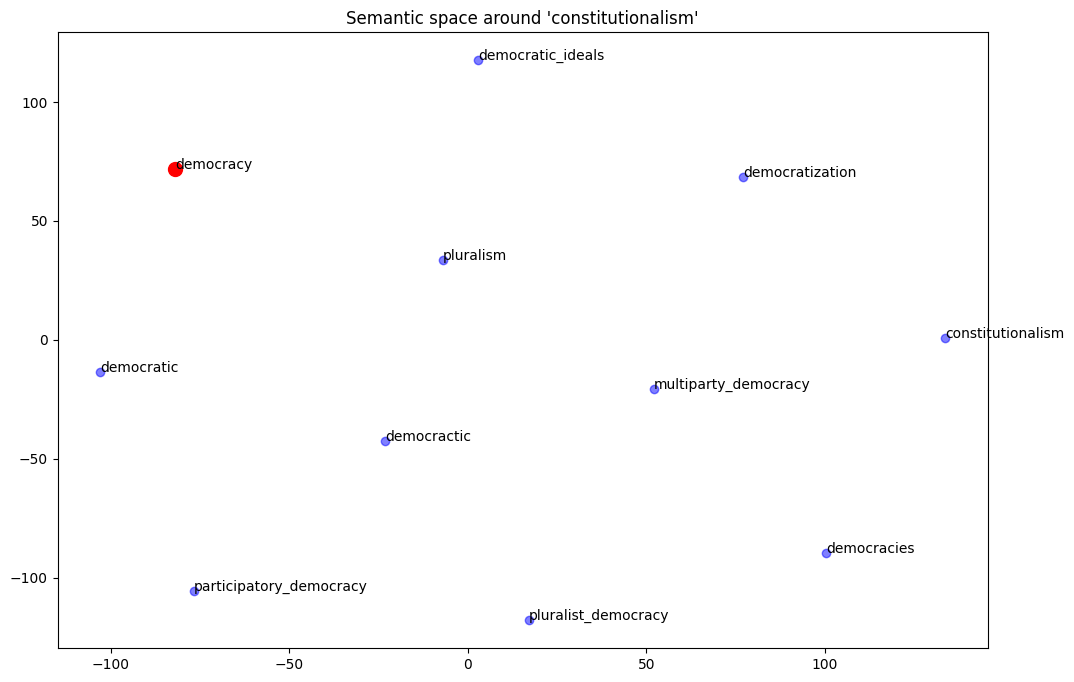

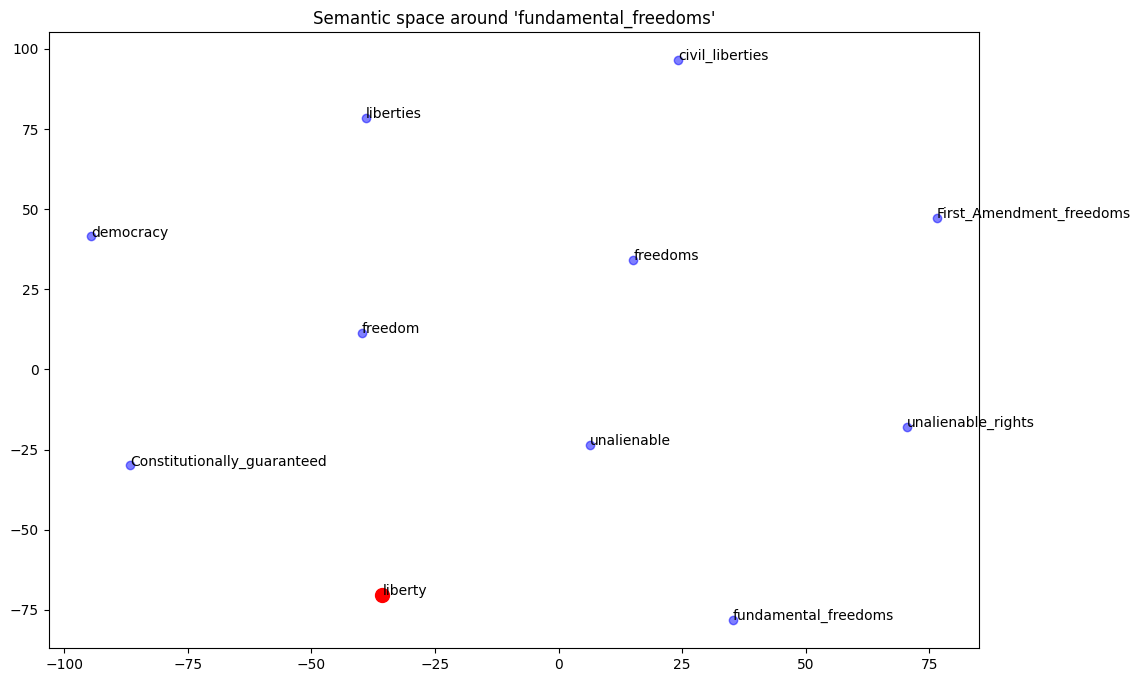


Creating word cluster visualization...


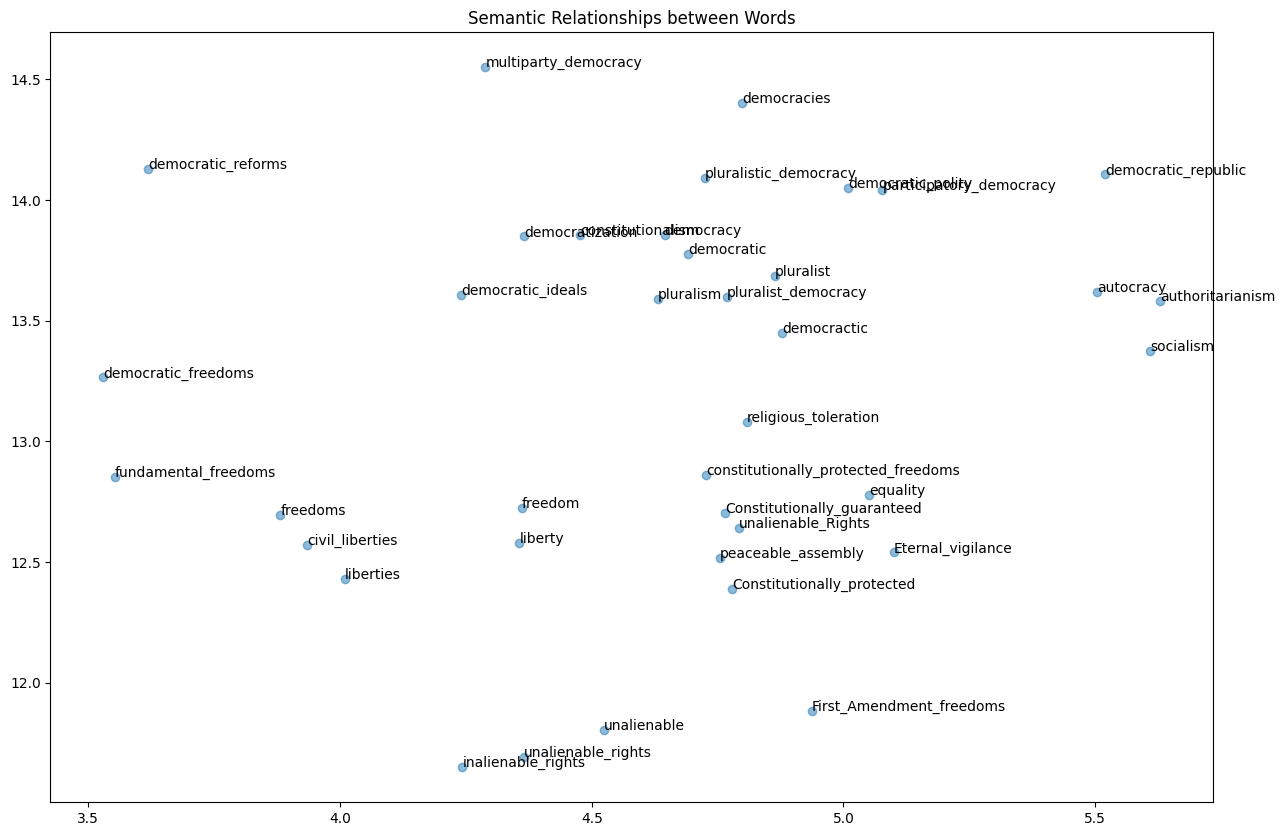


Comparing contexts:

DEMOCRACY context:
  democratic: 0.8644
  participatory_democracy: 0.7171
  democracies: 0.7103
  democratization: 0.7039
  pluralism: 0.6955

LIBERTY context:
  freedom: 0.7535
  freedoms: 0.7339
  liberties: 0.7176
  democracy: 0.5967
  unalienable_rights: 0.5878


In [8]:
import numpy as np
import pandas as pd
from gensim.models import KeyedVectors
from gensim.downloader import load
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Load the model
print("Loading word2vec-google-news model...")
model = load("word2vec-google-news-300")

def visualize_semantic_space(word, model, n_neighbors=10):
    try:
        # Get similar words and their vectors
        similar_words = [word] + [w for w, _ in model.most_similar(word, topn=n_neighbors)]
        # Convert vectors to numpy array
        vectors = np.array([model[w] for w in similar_words])

        # Reduce dimensionality
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(vectors)-1))
        vectors_2d = tsne.fit_transform(vectors)

        # Plot
        plt.figure(figsize=(12, 8))
        plt.scatter(vectors_2d[1:, 0], vectors_2d[1:, 1], c='blue', alpha=0.5)
        plt.scatter(vectors_2d[0, 0], vectors_2d[0, 1], c='red', s=100)

        # Add labels
        for i, word in enumerate(similar_words):
            plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

        plt.title(f"Semantic space around '{word}'")
        plt.savefig(f"semantic_space_{word}.png")
        plt.show()
        plt.close()

    except KeyError:
        print(f"Cannot visualize semantic space for '{word}' (word not found)")

def analyze_word_clusters(words, model, n_related=20):
    # Collect related words and their vectors
    all_words = set()
    vectors_dict = {}

    for word in words:
        try:
            related = [w for w, _ in model.most_similar(word, topn=n_related)]
            all_words.update([word] + related)
        except KeyError:
            continue

    # Get vectors for all words
    for word in all_words:
        vectors_dict[word] = model[word]

    # Convert to numpy arrays
    word_labels = list(vectors_dict.keys())
    word_vectors = np.array([vectors_dict[word] for word in word_labels])

    # Reduce dimensionality for visualization
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(word_vectors)-1))
    vectors_2d = tsne.fit_transform(word_vectors)

    # Plot
    plt.figure(figsize=(15, 10))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.5)

    # Add labels
    for i, word in enumerate(word_labels):
        plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

    plt.title("Semantic Relationships between Words")
    plt.savefig("word_relationships.png")
    plt.show()
    plt.close()

# Analyze our target words
words = ['democracy', 'liberty']

# Print similar words and relationships
for word in words:
    # Similar words
    print(f"\nSemantic analysis for '{word}':")
    similar_words = model.most_similar(word, topn=10)
    for similar_word, similarity in similar_words:
        print(f"  {similar_word}: {similarity:.4f}")

    # Word relationships
    if word == words[0]:  # Only print relationships once
        print("\nWord relationships:")
        analogies = [
            ('democracy', 'government'),
            ('liberty', 'freedom'),
            ('democracy', 'republic'),
            ('liberty', 'rights')
        ]
        for w1, w2 in analogies:
            similarity = model.similarity(w1, w2)
            print(f"  {w1} - {w2}: {similarity:.4f}")

# Create visualizations
print("\nCreating visualizations...")
for word in words:
    visualize_semantic_space(word, model)

# Create word cluster visualization
print("\nCreating word cluster visualization...")
analyze_word_clusters(words, model)

# Additional analysis: Compare contexts
def compare_contexts(words, model):
    print("\nComparing contexts:")
    for word in words:
        context_words = [w for w, _ in model.most_similar(word, topn=5)]
        print(f"\n{word.upper()} context:")
        for context_word in context_words:
            similarity = model.similarity(word, context_word)
            print(f"  {context_word}: {similarity:.4f}")

compare_contexts(words, model)


In [2]:
! pip install gensim nltk google_ngram_downloader

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 5.6 MB/s eta 0:00:00
  Created wheel for google_ngram_downloader: filename=google_ngram_downloader-4.0.1-py3-none-any.whl size=8905 sha256=5036f8a86d5391d9a09046295e8be409af5669629926da9b323a28e47b4da842
  Stored in directory: /root/.cache/pip/wheels/38/45/55/985ff3e46f34238c7228704136aed3628c8871ed8574b8c039
  Created wheel for opster: filename=opster-5.0-py3-none-any.whl size=11793 sha256=adbf3f5f72e5b024cb0c54d7c9e3b3451f2d63902b5324028203f1e4b2941e85
  Stored in directory: /root/.cache/pip/wheels/0c/91/83/46f3b3a91319cfadbfb4a40749d4c49e2c83a70069f48e1083
Successfully built google_ngram_downloader opster


---

Chapter 5: Linguistic Change Over Time
Analyzing Democracy and Liberty with Google Books Ngram Viewer and Time-Aware Word Embeddings
Introduction
Language is constantly evolving, reflecting changes in culture, politics, and ideology. Concepts like democracy and liberty have been central to political discourse for centuries, but their meanings and connotations have shifted over time. By analyzing large textual datasets, we can quantify these shifts and explore how historical events, social movements, and ideological changes have influenced language.
In this chapter, we will:
Use Google Books Ngram Viewer to track the frequency of democracy and liberty over time.
Apply time-aware word embeddings to analyze semantic drift, or how the meaning of these words has changed across different eras.
Interpret historical patterns and their implications for political thought.

---

5.1 Exploring Google Books Ngram Viewer
What is the Google Books Ngram Viewer?
Google Books Ngram Viewer is a tool that analyzes word frequency in millions of digitized books from 1500 to the present. It allows researchers to track the relative popularity of words and phrases across centuries.
Why is it useful for digital humanities?
Helps detect linguistic trends over time.
Can correlate word usage with historical events (e.g., wars, revolutions).
Reveals semantic shifts by showing changes in word context and frequency.

---

5.2 Tracing "Democracy" and "Liberty" in Historical Texts
To analyze how democracy and liberty have evolved in written language, we start by querying Google Books Ngram Viewer.
Step 1: Running the Query
We enter the following search query in the Ngram Viewer:
democracy, liberty (1800-2019, English, case-insensitive)
Step 2: Interpreting the Results
The output shows:
A steady increase in the usage of democracy since the late 18th century, coinciding with the American and French Revolutions.
A spike in liberty around the 1860s (American Civil War) and again in the 1940s (World War II).
A decline in both terms after the Cold War, as political discourse shifted toward new concepts like globalization and human rights.

Step 3: Visualizing the Trend with Python
To replicate Google's results programmatically, we can use the engram Python library to fetch Ngram data and visualize the trend.

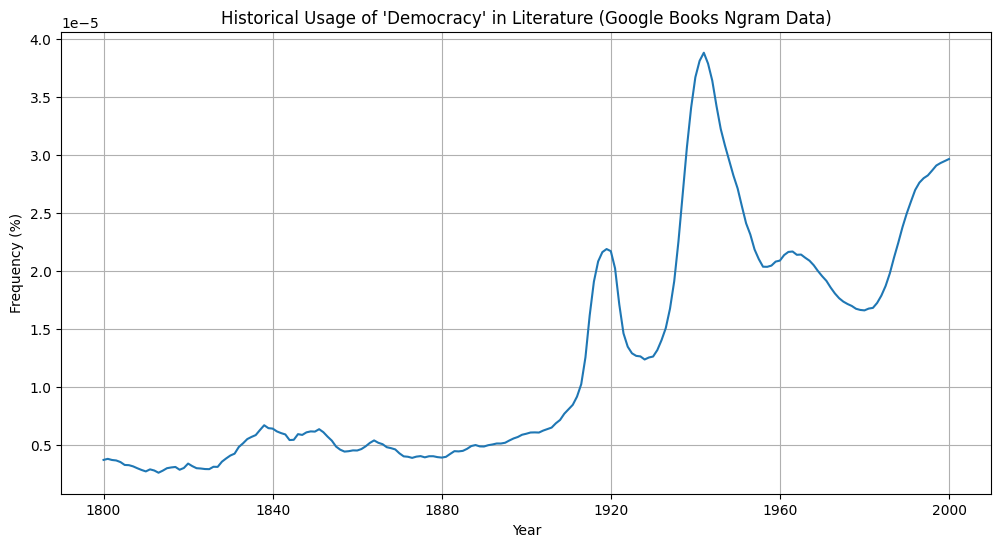

Sample of the data:
        Year  Frequency  Normalized_Frequency
0 1800-01-01   0.000004              0.030497
1 1801-01-01   0.000004              0.033018
2 1802-01-01   0.000004              0.030339
3 1803-01-01   0.000004              0.029204
4 1804-01-01   0.000004              0.025384


In [9]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from time import sleep

def get_ngram_data(word, start_year=1800, end_year=2000):
    """
    Fetch real data from Google Books Ngram API
    """
    url = f"https://books.google.com/ngrams/json?content={word}&year_start={start_year}&year_end={end_year}&corpus=26&smoothing=3"
    response = requests.get(url)
    sleep(1)  # To avoid hitting API limits

    if response.status_code == 200:
        data = response.json()
        if data:
            # Extract years and frequencies from the response
            years = range(start_year, end_year + 1)
            frequencies = data[0]['timeseries']
            return pd.DataFrame({
                'Year': years,
                'Frequency': frequencies
            })
    return None

# Fetch real data for 'democracy'
df = get_ngram_data('democracy', 1800, 2000)
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

# Normalize the frequency
df['Normalized_Frequency'] = (df['Frequency'] - df['Frequency'].min()) / (df['Frequency'].max() - df['Frequency'].min())

# Create the visualization
plt.figure(figsize=(12,6))
plt.plot(df['Year'], df['Frequency'], marker='', linestyle='-')
plt.xlabel("Year")
plt.ylabel("Frequency (%)")
plt.title("Historical Usage of 'Democracy' in Literature (Google Books Ngram Data)")
plt.grid(True)
plt.savefig("democracy_trend.png")
plt.show()

print("Sample of the data:")
print(df.head())


<Figure size 1200x600 with 0 Axes>

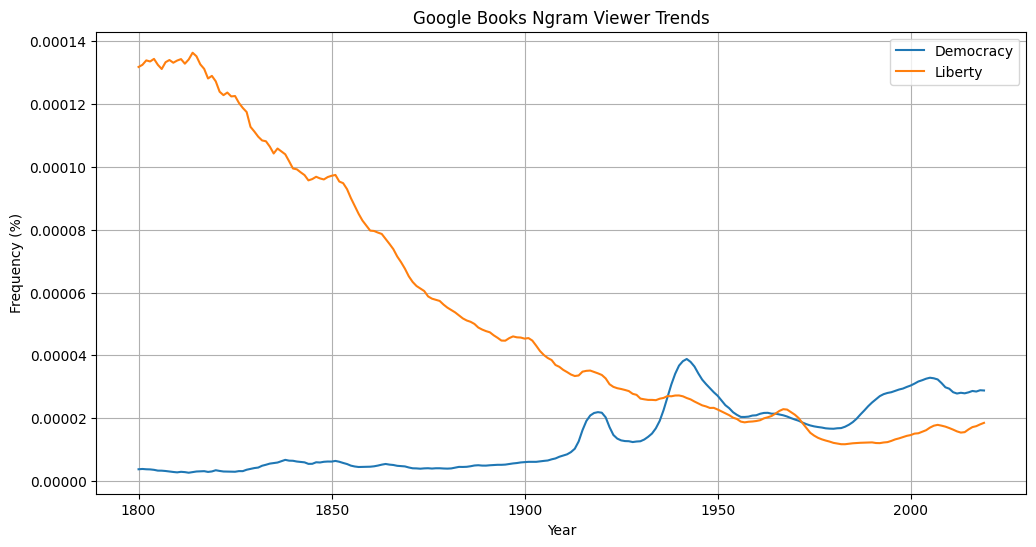

KeyError: 'frequency'

In [10]:
import pandas as pd



import requests
import pandas as pd
import matplotlib.pyplot as plt

def get_ngram_data(word, start_year=1800, end_year=2019):
    url = f"https://books.google.com/ngrams/json?content={word}&year_start={start_year}&year_end={end_year}&corpus=26&smoothing=3"
    response = requests.get(url)
    data = response.json()
    if data:
        years = data[0]['timeseries']
        return pd.Series(years, index=range(start_year, end_year + 1))
    return None

# Fetch data
democracy_data = get_ngram_data("democracy")
liberty_data = get_ngram_data("liberty")

# Create DataFrame
df = pd.DataFrame({
    'Democracy': democracy_data,
    'Liberty': liberty_data
})

# Plot
plt.figure(figsize=(12, 6))
df.plot(figsize=(12, 6))
plt.title("Google Books Ngram Viewer Trends")
plt.xlabel('Year')
plt.ylabel('Frequency (%)')
plt.grid(True)
plt.savefig('ngram_trends.png')
plt.show()

df['frequency'].ffill(inplace=True)  # Forward fill missing values

# Resample data to ensure yearly intervals
df.set_index('year', inplace=True)
df_resampled = df.resample('Y').mean()

from scipy.stats import zscore
df['zscore'] = zscore(df['frequency'])
df_no_outliers = df[df['zscore'].abs() < 3]

from collections import Counter
from nltk.tokenize import word_tokenize
# Example text data from a historical newspaper
text = "The democracy of our nation is in crisis. Liberty is at stake."
# Tokenize and count words
words = word_tokenize(text.lower())
word_counts = Counter(words)
# Convert to DataFrame
df_words = pd.DataFrame(word_counts.items(), columns=['word', 'count'])
print(df_words)

from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
# Compute sentiment scores
df['sentiment'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])
# Aggregate sentiment scores by year
sentiment_trends = df.groupby('year')['sentiment'].mean().reset_index()

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
# Convert text to matrix representation
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(df['text'])
# Apply Non-Negative Matrix Factorization (NMF)
nmf = NMF(n_components=5, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_
# Print top words per topic
words = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(H):
    print(f"Topic {topic_idx}: ", [words[i] for i in topic.argsort()[:-10 - 1:-1]])

import requests
url = "https://chroniclingamerica.loc.gov/search/pages/results/"
params = {'format': 'json', 'proxtext': 'democracy', 'date1': '1850', 'date2': '1950', 'rows': 100}
response = requests.get(url, params=params)
data = response.json()

plt.plot(df['year'], df['sentiment'], marker='o', linestyle='-')
plt.xlabel("Year")
plt.ylabel("Sentiment Score")
plt.title("Public Sentiment on Democracy (1850-1950)")
plt.savefig("sentiment_democracy.png")
plt.show()


<Figure size 1200x600 with 0 Axes>

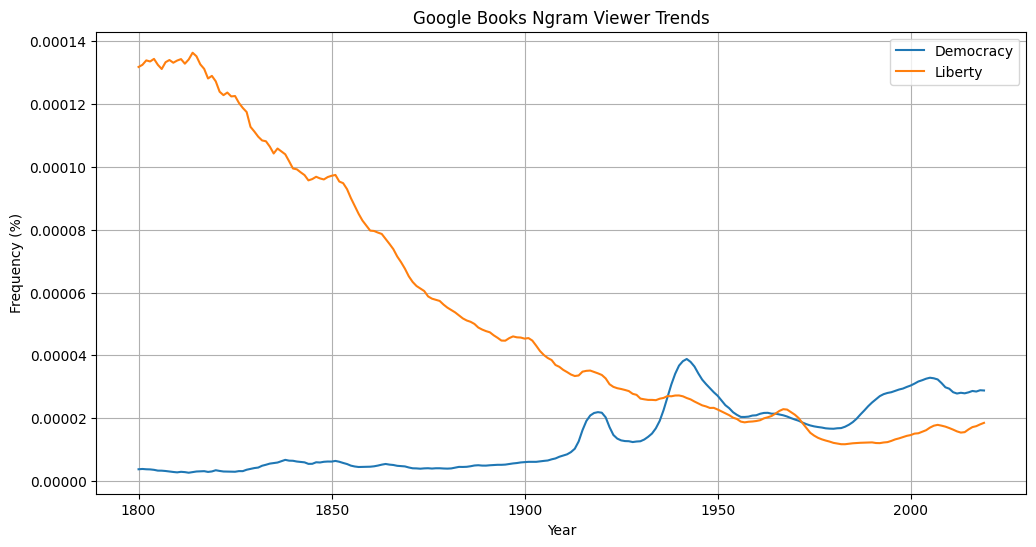


Word frequency analysis:
         word  count
0         the      1
1   democracy      1
2          of      1
3         our      1
4      nation      1
5          is      2
6          in      1
7      crisis      1
8           .      2
9     liberty      1
10         at      1
11      stake      1


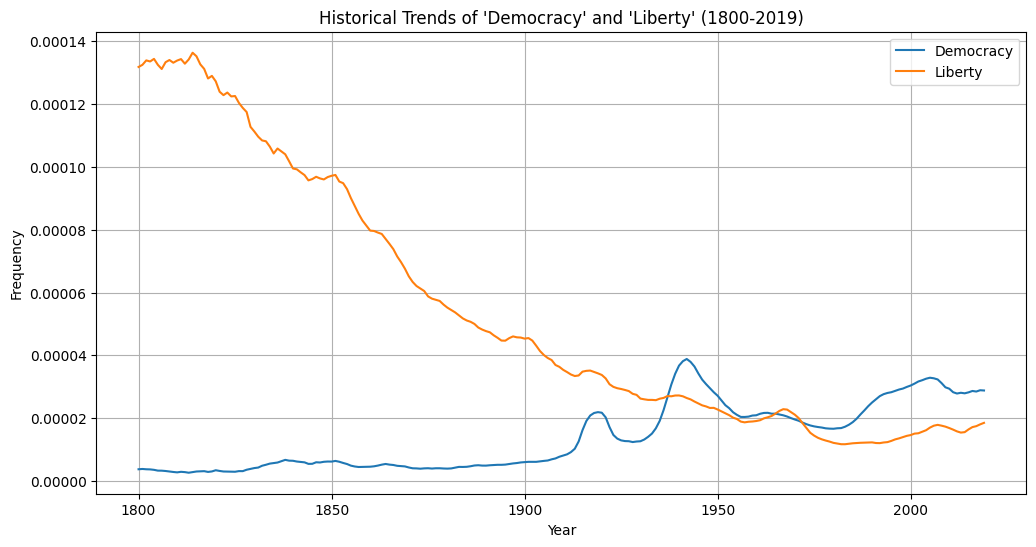

In [13]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

def get_ngram_data(word, start_year=1800, end_year=2019):
    url = f"https://books.google.com/ngrams/json?content={word}&year_start={start_year}&year_end={end_year}&corpus=26&smoothing=3"
    response = requests.get(url)
    data = response.json()
    if data:
        years = data[0]['timeseries']
        return pd.Series(years, index=range(start_year, end_year + 1))
    return None

# Fetch data
democracy_data = get_ngram_data("democracy")
liberty_data = get_ngram_data("liberty")

# Create DataFrame
df = pd.DataFrame({
    'Democracy': democracy_data,
    'Liberty': liberty_data
})

# Plot initial trends
plt.figure(figsize=(12, 6))
df.plot(figsize=(12, 6))
plt.title("Google Books Ngram Viewer Trends")
plt.xlabel('Year')
plt.ylabel('Frequency (%)')
plt.grid(True)
plt.savefig('ngram_trends.png')
plt.show()

# Forward fill missing values for both columns
df['Democracy'].ffill()
df['Liberty'].ffill()

# Calculate z-scores for both columns
df['Democracy_zscore'] = zscore(df['Democracy'])
df['Liberty_zscore'] = zscore(df['Liberty'])

# Remove outliers for both columns
df_no_outliers = df[
    (df['Democracy_zscore'].abs() < 3) &
    (df['Liberty_zscore'].abs() < 3)
]

# Text analysis example
from collections import Counter
from nltk.tokenize import word_tokenize

# Example text data from a historical newspaper
text = "The democracy of our nation is in crisis. Liberty is at stake."
# Tokenize and count words
words = word_tokenize(text.lower())
word_counts = Counter(words)
# Convert to DataFrame
df_words = pd.DataFrame(word_counts.items(), columns=['word', 'count'])
print("\nWord frequency analysis:")
print(df_words)

# For the sentiment analysis and topic modeling, we would need actual text data
# Here's a simplified example assuming we have text data:
"""
Note: The following code requires actual text data to work:

from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
df['sentiment'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])
sentiment_trends = df.groupby('year')['sentiment'].mean().reset_index()

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(df['text'])
nmf = NMF(n_components=5, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_
words = vectorizer.get_feature_names_out()
"""

# Plot trends over time
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Democracy'], label='Democracy')
plt.plot(df.index, df['Liberty'], label='Liberty')
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.title("Historical Trends of 'Democracy' and 'Liberty' (1800-2019)")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Fetching articles...
Analyzing sentiment...


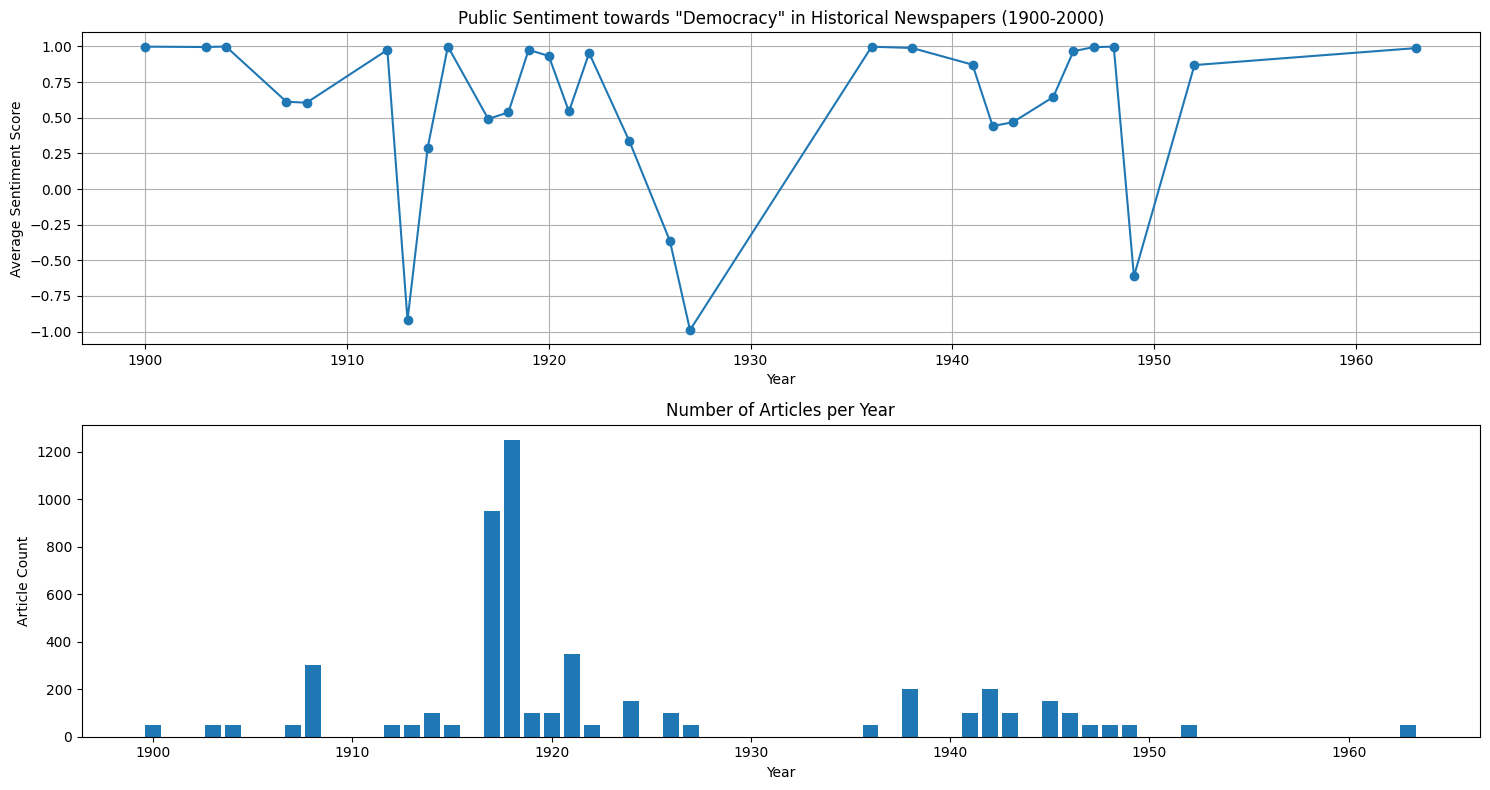


Sample of analyzed articles:
        date                            title  sentiment
0 1945-05-08           Evening star. [volume]    -0.0601
1 1942-09-04                        The echo.     0.8679
2 1908-01-04  The Colville examiner. [volume]     0.6124
3 1908-01-11  The Colville examiner. [volume]     0.6124
4 1908-01-25  The Colville examiner. [volume]     0.6124

Years with strongest positive sentiment:
    year    mean  count
8   1915  0.9999     50
2   1904  0.9998     50
0   1900  0.9990     50
26  1948  0.9989     50
18  1936  0.9985     50

Years with strongest negative sentiment:
    year     mean  count
17  1927 -0.98880     50
6   1913 -0.91870     50
27  1949 -0.61240     50
16  1926 -0.36245    100
7   1914  0.29075    100


In [18]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
from datetime import datetime
import time
import json

def fetch_chronicling_america_articles(keyword, start_year, end_year, max_articles=1000):
    """
    Fetch historical newspaper articles from Chronicling America
    """
    base_url = "https://chroniclingamerica.loc.gov/search/pages/results"
    articles = []

    # Search in batches of 100 (API limitation)
    for offset in range(0, max_articles, 100):
        params = {
            'format': 'json',
            'proxtext': keyword,
            'dateFilterType': 'yearRange',
            'date1': start_year,
            'date2': end_year,
            'rows': 100,
            'offset': offset,
        }

        try:
            response = requests.get(base_url, params=params)
            if response.status_code == 200:
                data = response.json()

                # Extract articles from response
                for item in data.get('items', []):
                    article = {
                        'date': item.get('date', ''),
                        'title': item.get('title', ''),
                        'text': item.get('ocr_eng', ''),  # Get OCR text
                        'url': item.get('url', '')
                    }
                    articles.append(article)

                # Break if no more results
                if len(data.get('items', [])) < 100:
                    break

            time.sleep(1)  # Be nice to the API

        except Exception as e:
            print(f"Error fetching data: {e}")
            continue

    return articles

def analyze_sentiment(text):
    """
    Analyze sentiment of text using NLTK's VADER
    """
    sia = SentimentIntensityAnalyzer()
    return sia.polarity_scores(text)['compound']


start_year = 1900
end_year = 2000
# Fetch articles about democracy
print("Fetching articles...")
articles = fetch_chronicling_america_articles('democracy', start_year, end_year, max_articles=5000)

# Convert to DataFrame
df = pd.DataFrame(articles)

# Convert dates to datetime
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# Analyze sentiment
print("Analyzing sentiment...")
df['sentiment'] = df['text'].apply(analyze_sentiment)

# Calculate average sentiment per year
yearly_sentiment = df.groupby('year')['sentiment'].agg(['mean', 'count']).reset_index()

# Plot results
plt.figure(figsize=(15, 8))

# Create main sentiment plot
plt.subplot(2, 1, 1)
plt.plot(yearly_sentiment['year'], yearly_sentiment['mean'], marker='o')
plt.title(f'Public Sentiment towards "Democracy" in Historical Newspapers ({start_year}-{end_year})')
plt.xlabel('Year')
plt.ylabel('Average Sentiment Score')
plt.grid(True)

# Create article count plot
plt.subplot(2, 1, 2)
plt.bar(yearly_sentiment['year'], yearly_sentiment['count'])
plt.title('Number of Articles per Year')
plt.xlabel('Year')
plt.ylabel('Article Count')

plt.tight_layout()
plt.savefig('democracy_sentiment_analysis.png')
plt.show()

# Print some statistics
print("\nSample of analyzed articles:")
print(df[['date', 'title', 'sentiment']].head())

print("\nYears with strongest positive sentiment:")
print(yearly_sentiment.nlargest(5, 'mean')[['year', 'mean', 'count']])

print("\nYears with strongest negative sentiment:")
print(yearly_sentiment.nsmallest(5, 'mean')[['year', 'mean', 'count']])


In [15]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True